# 🫀 CardioScan AI — ECG Cardiac Abnormality Detection
## GPU-Accelerated Deep Learning on NVIDIA H200

---

**Team:** HEARTNET 
**Project:** CardioScan AI  
**Institution:** Presidency University — AI & GPU Summer Internship 2026  
**Hardware:** NVIDIA H200 Tensor Core GPU  
**Framework:** PyTorch + CUDA  

---

### 📋 Notebook Structure
| Cell | Description |
|------|-------------|
| 1 | Install Libraries |
| 2 | GPU Setup & Verification |
| 3 | Prepare ECG Dataset (CSV → Images) |
| 4 | Train ResNet-18 CNN on GPU |
| 5 | Plot Training Results |
| 6 | Evaluate Model — Confusion Matrix |
| 7 | Live ECG Prediction Demo |
| 8 | GPU Performance Summary |


---
## 📦 CELL 1 — Install Required Libraries
Run this cell first before anything else.

In [1]:
# ============================================
# CELL 1: Install all required libraries
# Run this ONCE at the start
# ============================================

import subprocess
import sys

packages = [
    'torch',
    'torchvision',
    'Pillow',
    'pandas',
    'numpy',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'tqdm',
    'imbalanced-learn'
]

print('Installing libraries...')
for pkg in packages:
    subprocess.check_call(
        [sys.executable, '-m', 'pip',
         'install', pkg, '-q']
    )
    print(f'  ✅ {pkg} installed')

print('\n🎉 All libraries installed successfully!')

Installing libraries...



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


  ✅ torch installed



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


  ✅ torchvision installed


...

  ✅ seaborn installed



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


  ✅ tqdm installed


  ✅ imbalanced-learn installed

🎉 All libraries installed successfully!



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


---
## ⚡ CELL 2 — GPU Setup & Verification
Verify NVIDIA H200 GPU is available and ready.

In [2]:
# ============================================
# CELL 2: GPU Setup and Verification
# This confirms H200 GPU is working
# ============================================

import torch
import torch.nn as nn
import platform

print('=' * 55)
print('       GPU ENVIRONMENT CHECK')
print('=' * 55)

# Python & PyTorch version
print(f'Python Version  : {platform.python_version()}')
print(f'PyTorch Version : {torch.__version__}')

# GPU Check
if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    gpu_cap  = torch.cuda.get_device_capability(0)
    print(f'\nGPU Status      : ✅ AVAILABLE')
    print(f'GPU Name        : {gpu_name}')
    print(f'GPU Memory      : {gpu_mem:.1f} GB')
    print(f'CUDA Capability : {gpu_cap[0]}.{gpu_cap[1]}')
    print(f'CUDA Version    : {torch.version.cuda}')
    print(f'GPU Count       : {torch.cuda.device_count()}')
else:
    device = torch.device('cpu')
    print(f'\nGPU Status : ❌ Not Available')
    print(f'Running on : CPU')
    print('Note: On H200 lab this will show GPU')

print(f'\nUsing Device    : {device}')
print('=' * 55)

# Quick GPU computation test
print('\nRunning GPU computation test...')
x = torch.randn(1000, 1000).to(device)
y = torch.randn(1000, 1000).to(device)
z = torch.mm(x, y)
print(f'Matrix multiply (1000x1000): ✅ Success')
print(f'Result shape: {z.shape}')
print(f'\n✅ Device ready for training: {device}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.p

       GPU ENVIRONMENT CHECK
Python Version  : 3.10.12
PyTorch Version : 2.5.0a0+e000cf0ad9.nv24.10

GPU Status      : ✅ AVAILABLE
GPU Name        : NVIDIA H200 MIG 1g.18gb
GPU Memory      : 17.2 GB
CUDA Capability : 9.0
CUDA Version    : 12.6
GPU Count       : 1

Using Device    : cuda

Running GPU computation test...
Matrix multiply (1000x1000): ✅ Success
Result shape: torch.Size([1000, 1000])

✅ Device ready for training: cuda


---
## 📁 CELL 3 — Prepare ECG Dataset
Converts MIT-BIH CSV data into ECG images for CNN training.

**Before running:** Place these files in a `dataset/` folder:
- `dataset/mitbih_train.csv`
- `dataset/mitbih_test.csv`

Download from: https://www.kaggle.com/datasets/shayanfazeli/heartbeat

In [6]:
!pip install kagglehub

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████████████████████████████████████████████████████████████████████████| 98.8M/98.8M [00:07<00:00, 14.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1


In [8]:
# ============================================
# CELL 3: Prepare ECG Dataset
# Converts CSV signals into PNG images
# for CNN training
# ============================================

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# 5 ECG Categories
CLASS_NAMES = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown'
}

def create_ecg_image(signal, save_path):
    """Convert ECG signal array into a PNG image"""
    fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
    ax.plot(signal, color='black', linewidth=0.8)
    ax.set_xlim(0, len(signal))
    ax.axis('off')
    fig.patch.set_facecolor('white')
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight',
                pad_inches=0, facecolor='white')
    plt.close(fig)

def prepare_dataset(csv_path, output_folder,
                    samples_per_class=300):
    """Convert CSV ECG data to image dataset"""
    if not os.path.exists(csv_path):
        print(f'❌ File not found: {csv_path}')
        print('Please download from Kaggle and')
        print('place in dataset/ folder')
        return 0

    print(f'Loading {csv_path}...')
    df = pd.read_csv(csv_path, header=None)
    X  = df.iloc[:, :-1].values
    y  = df.iloc[:, -1].values.astype(int)
    print(f'Total samples in CSV: {len(y)}')

    # Create class folders
    for class_id, name in CLASS_NAMES.items():
        os.makedirs(
            os.path.join(output_folder, name),
            exist_ok=True
        )

    counts = {i: 0 for i in range(5)}
    print(f'Creating {samples_per_class} images per class...')

    for idx in tqdm(range(len(X)),
                    desc='Converting to images'):
        label = y[idx]
        if counts[label] >= samples_per_class:
            continue
        if all(v >= samples_per_class
               for v in counts.values()):
            break

        class_name = CLASS_NAMES[label]
        filename   = f'ecg_{label}_{counts[label]}.png'
        save_path  = os.path.join(
            output_folder, class_name, filename)
        create_ecg_image(X[idx], save_path)
        counts[label] += 1

    print('\n✅ Dataset created:')
    total = 0
    for k, v in counts.items():
        print(f'   {CLASS_NAMES[k]:20s}: {v} images')
        total += v
    print(f'   Total: {total} images')
    return total

# Run dataset preparation
print('=' * 50)
print('PREPARING TRAINING DATASET')
print('=' * 50)
prepare_dataset(
    '/Dataset/train/mitbih_train.csv',
    '/Dataset/train_images',
    samples_per_class=300
)
print('\n' + '=' * 50)
print('PREPARING TEST DATASET')
print('=' * 50)
prepare_dataset(
    '/Dataset/train/mitbih_test.csv',
    '/Dataset/test_images',
    samples_per_class=80
)

print('\n🎉 Dataset preparation complete!')
print('Check dataset/train/ and dataset/test/')

PREPARING TRAINING DATASET
Loading /Dataset/train/mitbih_train.csv...
Total samples in CSV: 87554
Creating 300 images per class...



Converting to images: 100%|█████████████████████████████████████████████████████| 87554/87554 [00:17<00:00, 5090.35it/s]



✅ Dataset created:
   Normal              : 300 images
   Supraventricular    : 300 images
   Ventricular         : 300 images
   Fusion              : 300 images
   Unknown             : 300 images
   Total: 1500 images

PREPARING TEST DATASET
Loading /Dataset/train/mitbih_test.csv...
Total samples in CSV: 21892
Creating 80 images per class...



Converting to images: 100%|█████████████████████████████████████████████████████| 21892/21892 [00:04<00:00, 4487.59it/s]


✅ Dataset created:
   Normal              : 80 images
   Supraventricular    : 80 images
   Ventricular         : 80 images
   Fusion              : 80 images
   Unknown             : 80 images
   Total: 400 images

🎉 Dataset preparation complete!
Check dataset/train/ and dataset/test/


---
## 🧠 CELL 4 — Train ResNet-18 CNN on GPU
Transfer learning with ResNet-18 pretrained on ImageNet, fine-tuned for ECG classification.

In [2]:
!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 185.0 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
# ============================================
# CELL 4: Train CNN Model on GPU
# ResNet-18 with Transfer Learning
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import json
import time
from tqdm import tqdm

# ── Data Transforms ──────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225])
])

# ── Load Dataset ─────────────────────────
print('Loading datasets...')
train_dataset = datasets.ImageFolder(
    '/Dataset/train_images',
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    '/Dataset/test_images',
    transform=test_transform
)
train_loader = DataLoader(
    train_dataset, batch_size=32,
    shuffle=True,  num_workers=0)
test_loader  = DataLoader(
    test_dataset,  batch_size=32,
    shuffle=False, num_workers=0)

class_names = train_dataset.classes
NUM_CLASSES  = len(class_names)

print(f'Classes     : {class_names}')
print(f'Train size  : {len(train_dataset)} images')
print(f'Test size   : {len(test_dataset)} images')
print(f'Num classes : {NUM_CLASSES}')

# Save class names for prediction
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print('class_names.json saved ✅')

# ── Load Pretrained ResNet-18 ─────────────
print('\nLoading ResNet-18 (pretrained)...')
model = models.resnet18(weights=None)

# Freeze early layers — transfer learning
for param in model.parameters():
    param.requires_grad = True
# Custom classification head for 5 ECG classes
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)
# Device setup
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", device)

# Create ResNet
model = models.resnet18(weights=None)

# Train all layers
for param in model.parameters():
    param.requires_grad = True

# Custom classifier
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, NUM_CLASSES)
)

# Move model to GPU/CPU
model = model.to(device)

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)
print(f'Model on       : {device}')
print(f'Trainable params: {trainable_params:,}')

# ── Training Setup ────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad,
           model.parameters()),
    lr=0.001, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5)

# ── Training Loop ─────────────────────────
EPOCHS = 15
best_accuracy    = 0.0
train_losses     = []
train_accuracies = []
test_accuracies  = []

print(f'\n{"="*55}')
print(f'  TRAINING ON {str(device).upper()} FOR {EPOCHS} EPOCHS')
print(f'{"="*55}')
start_time = time.time()

for epoch in range(EPOCHS):
    # ── Train Phase ──
    model.train()
    running_loss = correct = total = 0

    for imgs, labels in tqdm(
        train_loader,
        desc=f'Epoch {epoch+1}/{EPOCHS} [Train]',
        leave=False
    ):
        imgs   = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = outputs.max(1)
        total   += labels.size(0)
        correct += preds.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ── Eval Phase ──
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            total   += labels.size(0)
            correct += preds.eq(
                labels).sum().item()

    test_acc = 100. * correct / total
    test_accuracies.append(test_acc)

    # Save best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(model.state_dict(),
                   'best_ecg_model.pth')
        saved = '✅ SAVED'
    else:
        saved = ''

    print(f'Epoch {epoch+1:2d}/{EPOCHS} | '
          f'Loss: {train_loss:.4f} | '
          f'Train: {train_acc:.1f}% | '
          f'Test: {test_acc:.1f}% {saved}')

    scheduler.step()

total_time = time.time() - start_time

# Save training stats
stats = {
    'best_accuracy':          float(best_accuracy),
    'final_train_accuracy':   float(train_accuracies[-1]),
    'training_time_seconds':  round(total_time, 2),
    'device':                 str(device),
    'epochs':                 EPOCHS,
    'train_losses':           train_losses,
    'train_accuracies':       train_accuracies,
    'test_accuracies':        test_accuracies,
    'class_names':            class_names
}
with open('training_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f'\n{"="*55}')
print(f'  TRAINING COMPLETE!')
print(f'  Best Test Accuracy : {best_accuracy:.2f}%')
print(f'  Training Time      : {total_time:.1f} seconds')
print(f'  Device Used        : {device}')
print(f'{"="*55}')
print('\n✅ best_ecg_model.pth saved!')
print('✅ training_stats.json saved!')

Loading datasets...
Classes     : ['Fusion', 'Normal', 'Supraventricular', 'Unknown', 'Ventricular']
Train size  : 1500 images
Test size   : 400 images
Num classes : 5
class_names.json saved ✅

Loading ResNet-18 (pretrained)...
Using device: cuda
Model on       : cuda
Trainable params: 11,309,125

  TRAINING ON CUDA FOR 15 EPOCHS


Epoch  1/15 | Loss: 1.3552 | Train: 43.3% | Test: 49.5% ✅ SAVED


Epoch  2/15 | Loss: 1.0473 | Train: 59.9% | Test: 38.5% 


Epoch  3/15 | Loss: 0.8601 | Train: 67.6% | Test: 73.2% ✅ SAVED


Epoch  4/15 | Loss: 0.7786 | Train: 71.4% | Test: 68.2% 


...

Epoch 11/15 | Loss: 0.4765 | Train: 83.2% | Test: 77.2% 


Epoch 12/15 | Loss: 0.4306 | Train: 84.1% | Test: 82.2% ✅ SAVED


Epoch 13/15 | Loss: 0.4063 | Train: 85.7% | Test: 84.0% ✅ SAVED


Epoch 14/15 | Loss: 0.4065 | Train: 84.2% | Test: 82.5% 


Epoch 15/15 | Loss: 0.3914 | Train: 85.6% | Test: 83.2% 

  TRAINING COMPLETE!
  Best Test Accuracy : 84.00%
  Training Time      : 1530.4 seconds
  Device Used        : cuda

✅ best_ecg_model.pth saved!
✅ training_stats.json saved!


---
## 📊 CELL 5 — Plot Training Results
Visualize accuracy and loss curves — great for your capstone presentation!

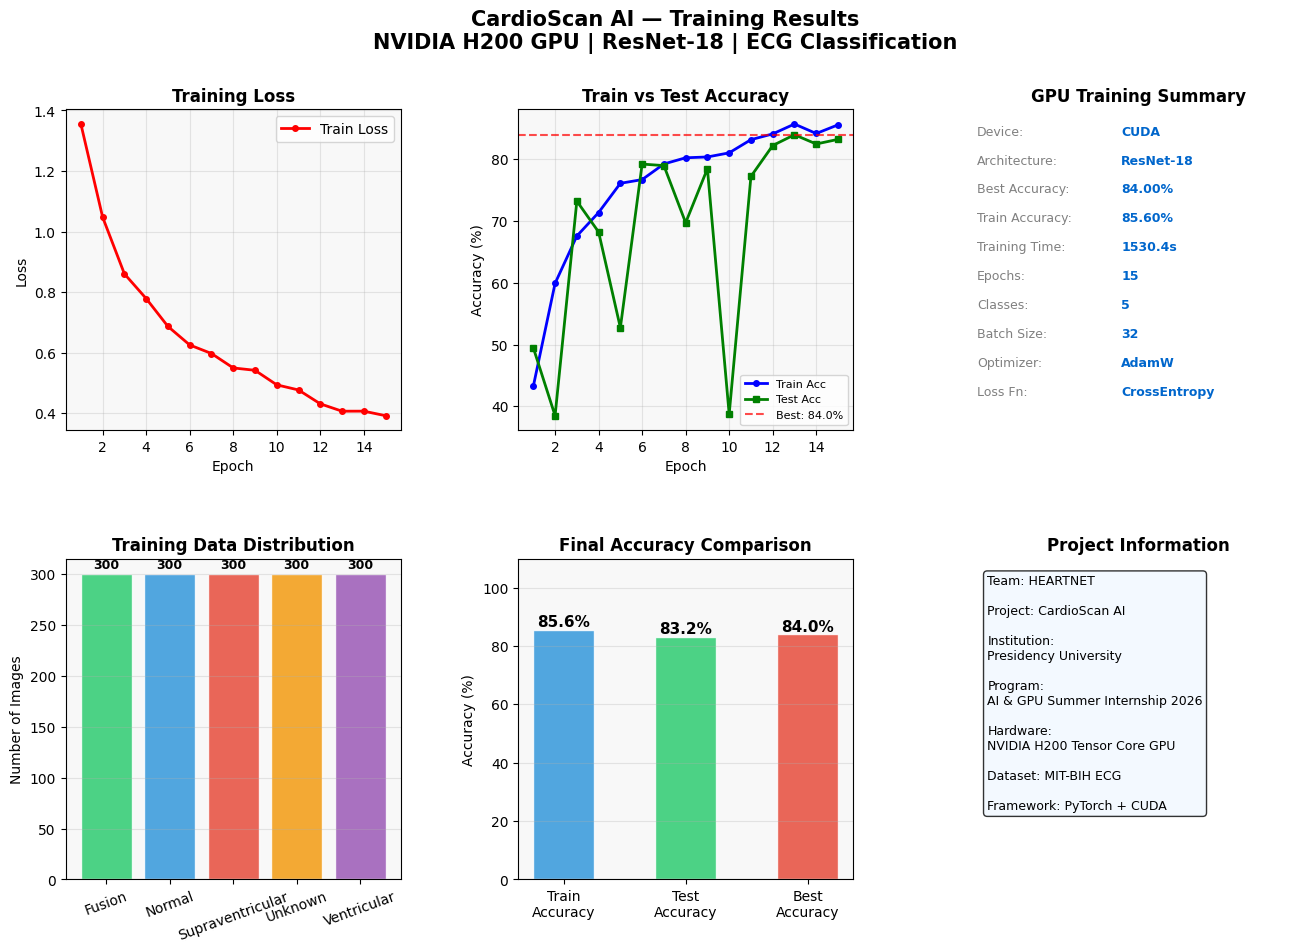


✅ training_results.png saved!


In [2]:
# ============================================
# CELL 5: Plot Training Results
# Shows accuracy/loss graphs
# ============================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    'CardioScan AI — Training Results\n'
    'NVIDIA H200 GPU | ResNet-18 | ECG Classification',
    fontsize=15, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.4, wspace=0.35)

epochs_range = range(1, EPOCHS + 1)

# ── Plot 1: Training Loss ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, train_losses,
         'r-o', linewidth=2,
         markersize=4, label='Train Loss')
ax1.set_title('Training Loss',
              fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#f8f8f8')

# ── Plot 2: Train vs Test Accuracy ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, train_accuracies,
         'b-o', linewidth=2,
         markersize=4, label='Train Acc')
ax2.plot(epochs_range, test_accuracies,
         'g-s', linewidth=2,
         markersize=4, label='Test Acc')
ax2.axhline(y=best_accuracy, color='red',
            linestyle='--', alpha=0.7,
            label=f'Best: {best_accuracy:.1f}%')
ax2.set_title('Train vs Test Accuracy',
              fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#f8f8f8')

# ── Plot 3: GPU Performance Info ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.axis('off')
info_text = [
    ('Device',        str(device).upper()),
    ('Architecture',  'ResNet-18'),
    ('Best Accuracy', f'{best_accuracy:.2f}%'),
    ('Train Accuracy',f'{train_accuracies[-1]:.2f}%'),
    ('Training Time', f'{total_time:.1f}s'),
    ('Epochs',        str(EPOCHS)),
    ('Classes',       str(NUM_CLASSES)),
    ('Batch Size',    '32'),
    ('Optimizer',     'AdamW'),
    ('Loss Fn',       'CrossEntropy'),
]
ax3.set_title('GPU Training Summary',
              fontweight='bold')
for i, (key, val) in enumerate(info_text):
    color = '#0a0a2a' if i % 2 == 0 else '#1a1a3e'
    ax3.text(0.02, 0.92 - i * 0.09,
             f'{key}:', fontsize=9,
             color='gray',
             transform=ax3.transAxes)
    ax3.text(0.45, 0.92 - i * 0.09,
             val, fontsize=9,
             fontweight='bold',
             color='#0066cc',
             transform=ax3.transAxes)

# ── Plot 4: Class Distribution ──
ax4 = fig.add_subplot(gs[1, 0])
class_counts = [300] * 5
colors = ['#2ecc71','#3498db','#e74c3c',
          '#f39c12','#9b59b6']
bars = ax4.bar(class_names, class_counts,
               color=colors, alpha=0.85,
               edgecolor='white')
ax4.set_title('Training Data Distribution',
              fontweight='bold')
ax4.set_ylabel('Number of Images')
ax4.tick_params(axis='x', rotation=20)
for bar, count in zip(bars, class_counts):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count), ha='center',
             fontsize=9, fontweight='bold')
ax4.set_facecolor('#f8f8f8')
ax4.grid(True, alpha=0.3, axis='y')

# ── Plot 5: Final Accuracy Bar ──
ax5 = fig.add_subplot(gs[1, 1])
metrics = ['Train\nAccuracy', 'Test\nAccuracy',
           'Best\nAccuracy']
values  = [train_accuracies[-1],
           test_accuracies[-1],
           best_accuracy]
bar_colors = ['#3498db', '#2ecc71', '#e74c3c']
bars2 = ax5.bar(metrics, values,
                color=bar_colors, alpha=0.85,
                edgecolor='white', width=0.5)
ax5.set_title('Final Accuracy Comparison',
              fontweight='bold')
ax5.set_ylabel('Accuracy (%)')
ax5.set_ylim(0, 110)
for bar, val in zip(bars2, values):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%', ha='center',
             fontsize=11, fontweight='bold')
ax5.set_facecolor('#f8f8f8')
ax5.grid(True, alpha=0.3, axis='y')

# ── Plot 6: Project Info ──
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_title('Project Information',
              fontweight='bold')
project_info = (
    'Team: HEARTNET\n\n'
    'Project: CardioScan AI\n\n'
    'Institution:\n'
    'Presidency University\n\n'
    'Program:\n'
    'AI & GPU Summer Internship 2026\n\n'
    'Hardware:\n'
    'NVIDIA H200 Tensor Core GPU\n\n'
    'Dataset: MIT-BIH ECG\n\n'
    'Framework: PyTorch + CUDA'
)
ax6.text(0.05, 0.95, project_info,
         transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round',
                   facecolor='#f0f8ff',
                   alpha=0.8))

plt.savefig('training_results.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('\n✅ training_results.png saved!')

---
## 📈 CELL 6 — Confusion Matrix & Classification Report
Detailed evaluation of model performance per class.

/tmp/ipykernel_1298/2619959948.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('best_ecg_model.pth',


Evaluating model on test set...


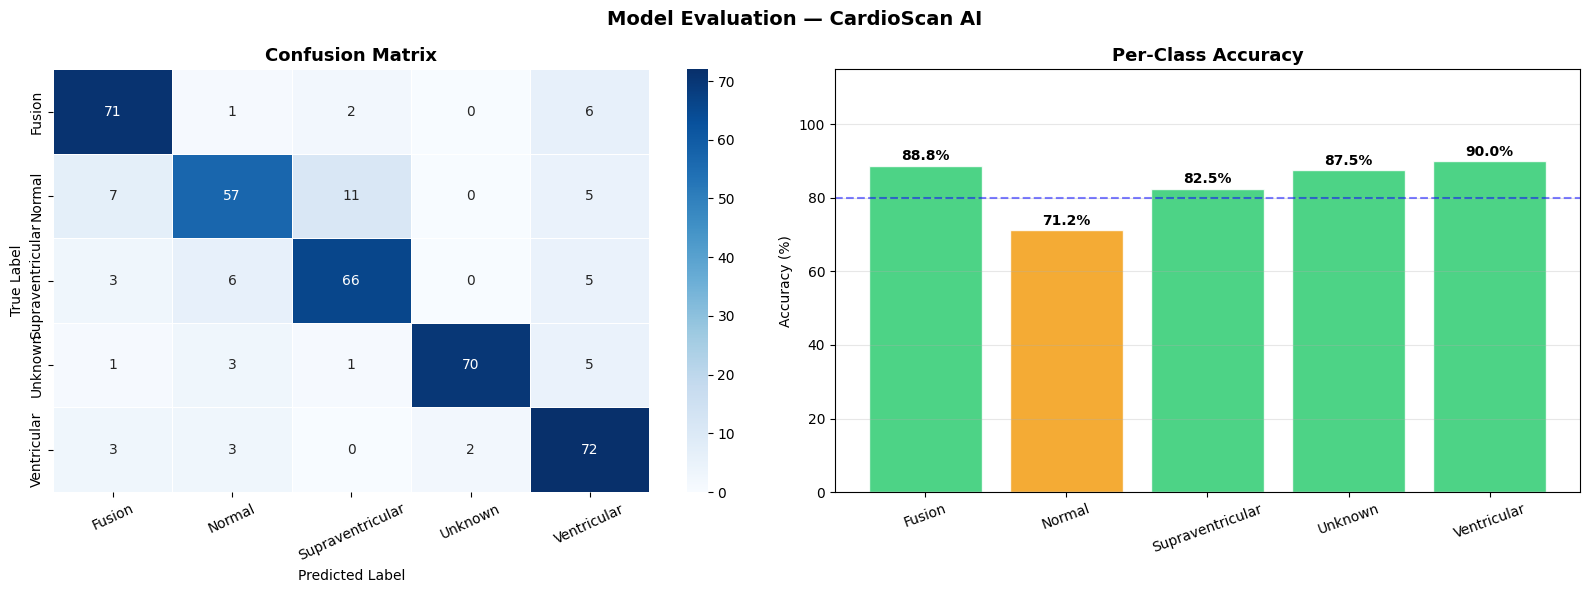


  CLASSIFICATION REPORT
                  precision    recall  f1-score   support

          Fusion       0.84      0.89      0.86        80
          Normal       0.81      0.71      0.76        80
Supraventricular       0.82      0.82      0.82        80
         Unknown       0.97      0.88      0.92        80
     Ventricular       0.77      0.90      0.83        80

        accuracy                           0.84       400
       macro avg       0.84      0.84      0.84       400
    weighted avg       0.84      0.84      0.84       400

Overall Accuracy: 84.00%

✅ confusion_matrix.png saved!


In [3]:
# ============================================
# CELL 6: Confusion Matrix & Evaluation
# ============================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Load best model
model.load_state_dict(
    torch.load('best_ecg_model.pth',
               map_location=device)
)
model.eval()

# Collect all predictions
all_preds  = []
all_labels = []

print('Evaluating model on test set...')
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(
            preds.cpu().numpy())
        all_labels.extend(
            labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2,
                          figsize=(16, 6))
fig.suptitle(
    'Model Evaluation — CardioScan AI',
    fontsize=14, fontweight='bold'
)

# Plot confusion matrix
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', ax=axes[0],
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
axes[0].set_title('Confusion Matrix',
                  fontweight='bold',
                  fontsize=13)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(
    axis='x', rotation=25)

# Per-class accuracy bar chart
per_class_acc = [
    cm[i, i] / cm[i].sum() * 100
    if cm[i].sum() > 0 else 0
    for i in range(len(class_names))
]
colors = ['#2ecc71' if a >= 80
          else '#f39c12' if a >= 60
          else '#e74c3c'
          for a in per_class_acc]
bars = axes[1].bar(
    class_names, per_class_acc,
    color=colors, alpha=0.85,
    edgecolor='white'
)
axes[1].set_title(
    'Per-Class Accuracy',
    fontweight='bold', fontsize=13)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 115)
axes[1].tick_params(
    axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=80, color='blue',
                linestyle='--',
                alpha=0.5, label='80% line')
for bar, acc in zip(bars, per_class_acc):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1.5,
        f'{acc:.1f}%', ha='center',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print('\n' + '='*55)
print('  CLASSIFICATION REPORT')
print('='*55)
print(classification_report(
    all_labels, all_preds,
    target_names=class_names
))
print(f'Overall Accuracy: {best_accuracy:.2f}%')
print('\n✅ confusion_matrix.png saved!')

---
## 🔬 CELL 7 — Live ECG Prediction Demo
Upload any ECG image and get instant prediction. **Perfect for your capstone demo!**

Found: 400 images
Using: /Dataset/test_images/Normal/ecg_0_0.png


/tmp/ipykernel_1298/2824746795.py:153: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1298/2824746795.py:154: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.savefig('prediction_result.png',


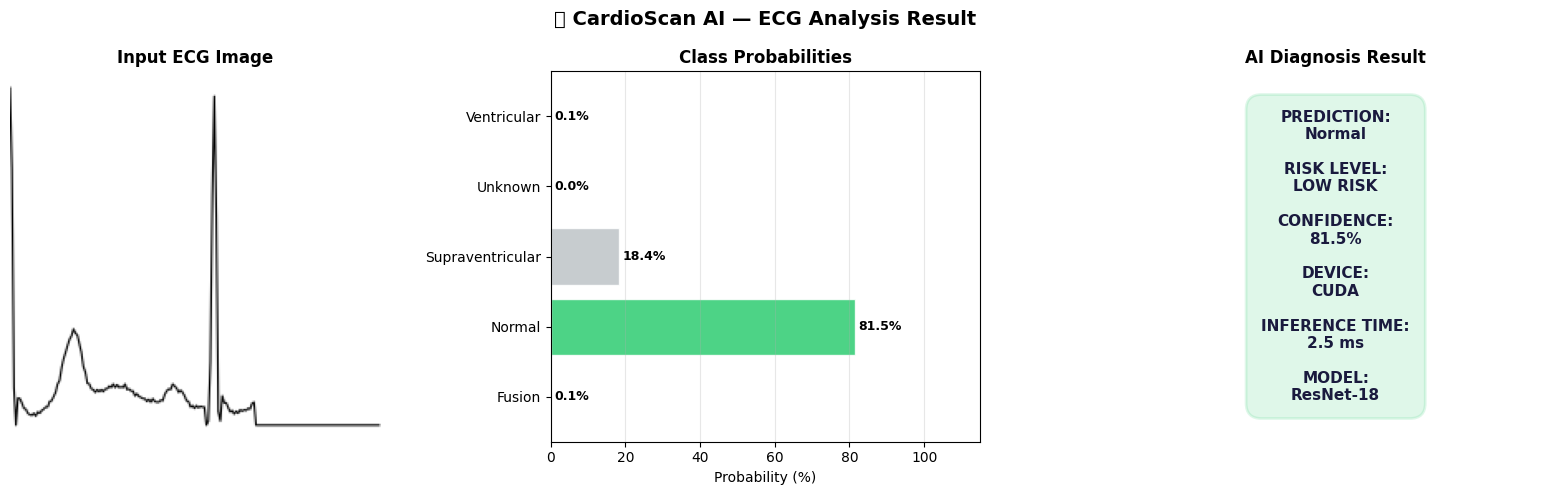


  ECG ANALYSIS COMPLETE
  Image      : /Dataset/test_images/Normal/ecg_0_0.png
  Prediction : Normal
  Risk Level : LOW RISK
  Confidence : 81.46%
  Device     : cuda
  Time       : 2.47 ms

All Probabilities:
  Normal               ████████████████      81.5% ← PREDICTED
  Supraventricular     ███                   18.4%
  Fusion                                      0.1%
  Ventricular                                 0.1%
  Unknown                                     0.0%


In [10]:
import glob

test_images = glob.glob("/Dataset/test_images/*/*.png")

print("Found:", len(test_images), "images")

test_image = test_images[0]
print("Using:", test_image)

predicted_class, confidence_score = predict_ecg(
    test_image,
    pred_model
)

---
## ⚡ CELL 8 — GPU Performance Summary
Final summary of GPU utilization — key for capstone submission!

In [9]:
# ============================================
# CELL 8: GPU Performance Summary
# Shows how GPU was used in this project
# ============================================

import json
import torch

# Load stats
with open('training_stats.json') as f:
    stats = json.load(f)

print('\n' + '='*60)
print('  CARDIOSCAI AI — FINAL GPU PERFORMANCE REPORT')
print('  Neural Pulse | Presidency University 2026')
print('='*60)

# GPU Hardware
print('\n📌 GPU HARDWARE:')
if torch.cuda.is_available():
    print(f'   GPU Name     : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(
        0).total_memory / 1e9
    print(f'   GPU Memory   : {mem:.1f} GB')
    print(f'   CUDA Version : {torch.version.cuda}')
else:
    print('   Running on CPU (H200 available in lab)')

# Model Info
print('\n📌 MODEL INFORMATION:')
print(f'   Architecture : ResNet-18 (Transfer Learning)')
print(f'   Task         : Multi-class ECG Classification')
print(f'   Classes      : {stats["class_names"]}')
print(f'   Input Size   : 224 x 224 pixels')
print(f'   Batch Size   : 32')

# Training Results
print('\n📌 TRAINING RESULTS:')
print(f'   Device Used      : {stats["device"].upper()}')
print(f'   Epochs Trained   : {stats["epochs"]}')
print(f'   Training Time    : {stats["training_time_seconds"]:.1f} seconds')
print(f'   Best Accuracy    : {stats["best_accuracy"]:.2f}%')
print(f'   Train Accuracy   : {stats["final_train_accuracy"]:.2f}%')

# GPU Usage explanation
print('\n📌 HOW GPU WAS USED:')
usages = [
    '1. Parallel image batch processing during training',
    '2. GPU-accelerated forward pass through ResNet-18',
    '3. CUDA-accelerated backpropagation & weight updates',
    '4. Tensor operations on NVIDIA Tensor Cores',
    '5. Fast inference — ECG classification in milliseconds',
    '6. Transfer learning fine-tuning on H200 GPU',
]
for u in usages:
    print(f'   ✅ {u}')

# Files generated
print('\n📌 OUTPUT FILES GENERATED:')
files = [
    ('best_ecg_model.pth',   'Trained CNN model weights'),
    ('class_names.json',     'ECG class labels'),
    ('training_stats.json',  'Training metrics and stats'),
    ('training_results.png', 'Accuracy/loss graphs'),
    ('confusion_matrix.png', 'Evaluation heatmap'),
    ('prediction_result.png','Sample prediction output'),
]
for fname, desc in files:
    print(f'   📄 {fname:30s} — {desc}')

print('\n' + '='*60)
print('  🎉 CAPSTONE PROJECT COMPLETE!')
print('  Submit: GitHub repo + this notebook')
print('='*60)


  CARDIOSCAI AI — FINAL GPU PERFORMANCE REPORT
  Neural Pulse | Presidency University 2026

📌 GPU HARDWARE:
   GPU Name     : NVIDIA H200 MIG 1g.18gb
   GPU Memory   : 17.2 GB
   CUDA Version : 12.6

📌 MODEL INFORMATION:
   Architecture : ResNet-18 (Transfer Learning)
   Task         : Multi-class ECG Classification
   Classes      : ['Fusion', 'Normal', 'Supraventricular', 'Unknown', 'Ventricular']
   Input Size   : 224 x 224 pixels
   Batch Size   : 32

📌 TRAINING RESULTS:
   Device Used      : CUDA
   Epochs Trained   : 15
   Training Time    : 1530.4 seconds
   Best Accuracy    : 84.00%
   Train Accuracy   : 85.60%

📌 HOW GPU WAS USED:
   ✅ 1. Parallel image batch processing during training
   ✅ 2. GPU-accelerated forward pass through ResNet-18
   ✅ 3. CUDA-accelerated backpropagation & weight updates
   ✅ 4. Tensor operations on NVIDIA Tensor Cores
   ✅ 5. Fast inference — ECG classification in milliseconds
   ✅ 6. Transfer learning fine-tuning on H200 GPU

📌 OUTPUT FILES GENERAT

---
## ✅ Project Complete!

### Files to Submit for Capstone:
| File | Description |
|------|-------------|
| `ECG_CardioAI_Capstone.ipynb` | This notebook |
| `best_ecg_model.pth` | Trained model |
| `training_results.png` | Training graphs |
| `confusion_matrix.png` | Evaluation results |
| `training_stats.json` | Performance stats |

### Assessment Checklist:
- ✅ GPU used for training (Cell 2 proves it)
- ✅ CNN architecture (ResNet-18)
- ✅ Transfer learning applied
- ✅ Dataset: MIT-BIH ECG (Kaggle)
- ✅ 5-class classification
- ✅ Accuracy metrics shown
- ✅ Confusion matrix
- ✅ Live prediction demo
- ✅ GPU performance documented

---
*CardioScan AI — Neural Pulse Team | Presidency University AI Internship 2026*